In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from tensorflow.keras import layers # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore
from tensorflow.keras.models import load_model # type: ignore
from tensorflow.keras.utils import plot_model # type: ignore
from time import perf_counter 
import os

In [2]:
## Defining batch specfications
batch_size = 100
img_height = 250
img_width = 250

In [3]:
## loading training set
training_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/train',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 791 files belonging to 2 classes.


In [4]:
## loading validation dataset
validation_data =  tf.keras.preprocessing.image_dataset_from_directory(
    'data/val',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 98 files belonging to 2 classes.


In [5]:
## loading testing dataset
testing_data = tf.keras.preprocessing.image_dataset_from_directory(
    'data/test',
    seed=42,
    image_size= (img_height, img_width),
    batch_size=batch_size,
    color_mode='rgb'
)

Found 100 files belonging to 2 classes.


In [6]:
testing_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [7]:
class_names = training_data.class_names
class_names

['Accident', 'Non Accident']

In [8]:
## Configuring dataset for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE
training_data = training_data.cache().prefetch(buffer_size=AUTOTUNE)
testing_data = testing_data.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
## Defining Cnn
model = tf.keras.models.Sequential([
  layers.BatchNormalization(),
  layers.Conv2D(32, 3, activation='relu'), # Conv2D(f_size, filter_size, activation) # relu, sigmoid, softmax
  layers.MaxPooling2D(), # MaxPooling
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(512, activation='relu'),
  layers.Dense(len(class_names), activation= 'softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [10]:
model.build((None, 250, 250, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 250, 250, 3)    │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 248, 248, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    22,151,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,541,134 (85.99 MB)

 Trainable params: 22,541,128 (85.99 MB)

 Non-trainable params: 6 (24.00 B)

In [11]:
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [12]:
## lets train our CNN
checkpoint = ModelCheckpoint("model_weights.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]
history = model.fit(training_data, validation_data=validation_data, epochs = 20, callbacks=callbacks_list)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5140 - loss: 5.1629
Epoch 1: val_accuracy improved from None to 0.53061, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5360 - loss: 3.3690 - val_accuracy: 0.5306 - val_loss: 0.6868
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5448 - loss: 0.7020
Epoch 2: val_accuracy did not improve from 0.53061
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5436 - loss: 0.7187 - val_accuracy: 0.5306 - val_loss: 0.8361
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5758 - loss: 0.6734
Epoch 3: val_accuracy did not improve from 0.53061
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6068 - loss: 0.6632 - val_accuracy: 0.5306 - val_loss: 0.7538
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6360 - loss: 0.6342
Epoch 4: val_accuracy improved from 0.53061 to 0.67347, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6549 - loss: 0.6241 - val_accuracy: 0.6735 - val_loss: 0.6260
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6722 - loss: 0.5923
Epoch 5: val_accuracy did not improve from 0.67347
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6991 - loss: 0.5798 - val_accuracy: 0.6224 - val_loss: 0.6248
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7176 - loss: 0.5398
Epoch 6: val_accuracy improved from 0.67347 to 0.69388, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7459 - loss: 0.5199 - val_accuracy: 0.6939 - val_loss: 0.5651
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7657 - loss: 0.4840
Epoch 7: val_accuracy improved from 0.69388 to 0.75510, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7901 - loss: 0.4579 - val_accuracy: 0.7551 - val_loss: 0.5196
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7935 - loss: 0.3994
Epoch 8: val_accuracy improved from 0.75510 to 0.78571, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8217 - loss: 0.3732 - val_accuracy: 0.7857 - val_loss: 0.5515
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8371 - loss: 0.3538
Epoch 9: val_accuracy did not improve from 0.78571
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8609 - loss: 0.3163 - val_accuracy: 0.7347 - val_loss: 0.5925
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8914 - loss: 0.2393
Epoch 10: val_accuracy did not improve from 0.78571
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8951 - loss: 0.2294 - val_accuracy: 0.7143 - val_loss: 0.6506
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9201 - loss: 0.2147
Epoch 11: val_accuracy improved from 0.78571 to 0.81633, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9355 - loss: 0.1898 - val_accuracy: 0.8163 - val_loss: 0.4930
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9100 - loss: 0.1713
Epoch 12: val_accuracy improved from 0.81633 to 0.85714, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9128 - loss: 0.1803 - val_accuracy: 0.8571 - val_loss: 0.3434
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9458 - loss: 0.1548
Epoch 13: val_accuracy did not improve from 0.85714
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9456 - loss: 0.1422 - val_accuracy: 0.7857 - val_loss: 0.6345
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9400 - loss: 0.1409
Epoch 14: val_accuracy improved from 0.85714 to 0.87755, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9570 - loss: 0.1145 - val_accuracy: 0.8776 - val_loss: 0.4772
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9780 - loss: 0.0809
Epoch 15: val_accuracy improved from 0.87755 to 0.88776, saving model to model_weights.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9798 - loss: 0.0738 - val_accuracy: 0.8878 - val_loss: 0.4988
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9583 - loss: 0.0963
Epoch 16: val_accuracy did not improve from 0.88776
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9722 - loss: 0.0764 - val_accuracy: 0.8878 - val_loss: 0.4493
Epoch 17/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9604 - loss: 0.1066
Epoch 17: val_accuracy did not improve from 0.88776
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9608 - loss: 0.1033 - val_accuracy: 0.8673 - val_loss: 0.4814
Epoch 18/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9554 - loss: 0.1128
Epoch 18: val_accuracy did not improve from 0.88776
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9671 - loss: 0.0892 - val_accuracy: 0.8776 - val_loss: 0.3331
Epoch 19/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9735 - loss: 0.0589
Epoch 19: val_accuracy did not improve from 0.88776
8/8 ━━━━━━━━

In [13]:
###### serialize model structure to JSON
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

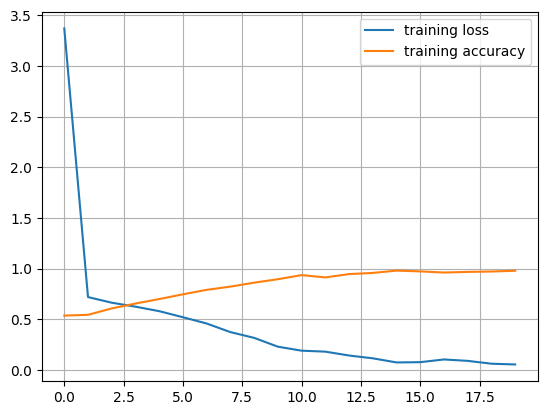

In [14]:
## stats on training data
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.grid(True)
plt.legend()

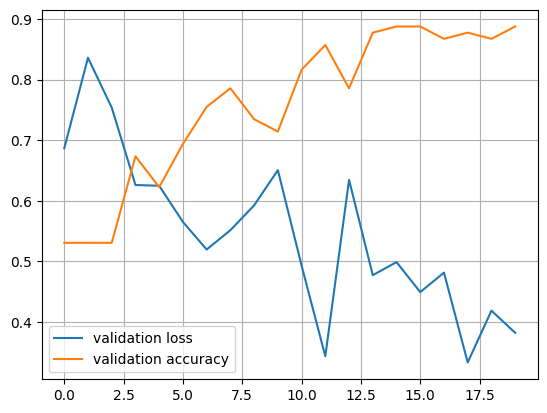

In [15]:
## stats on training data
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.grid(True)
plt.legend()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 524ms/step


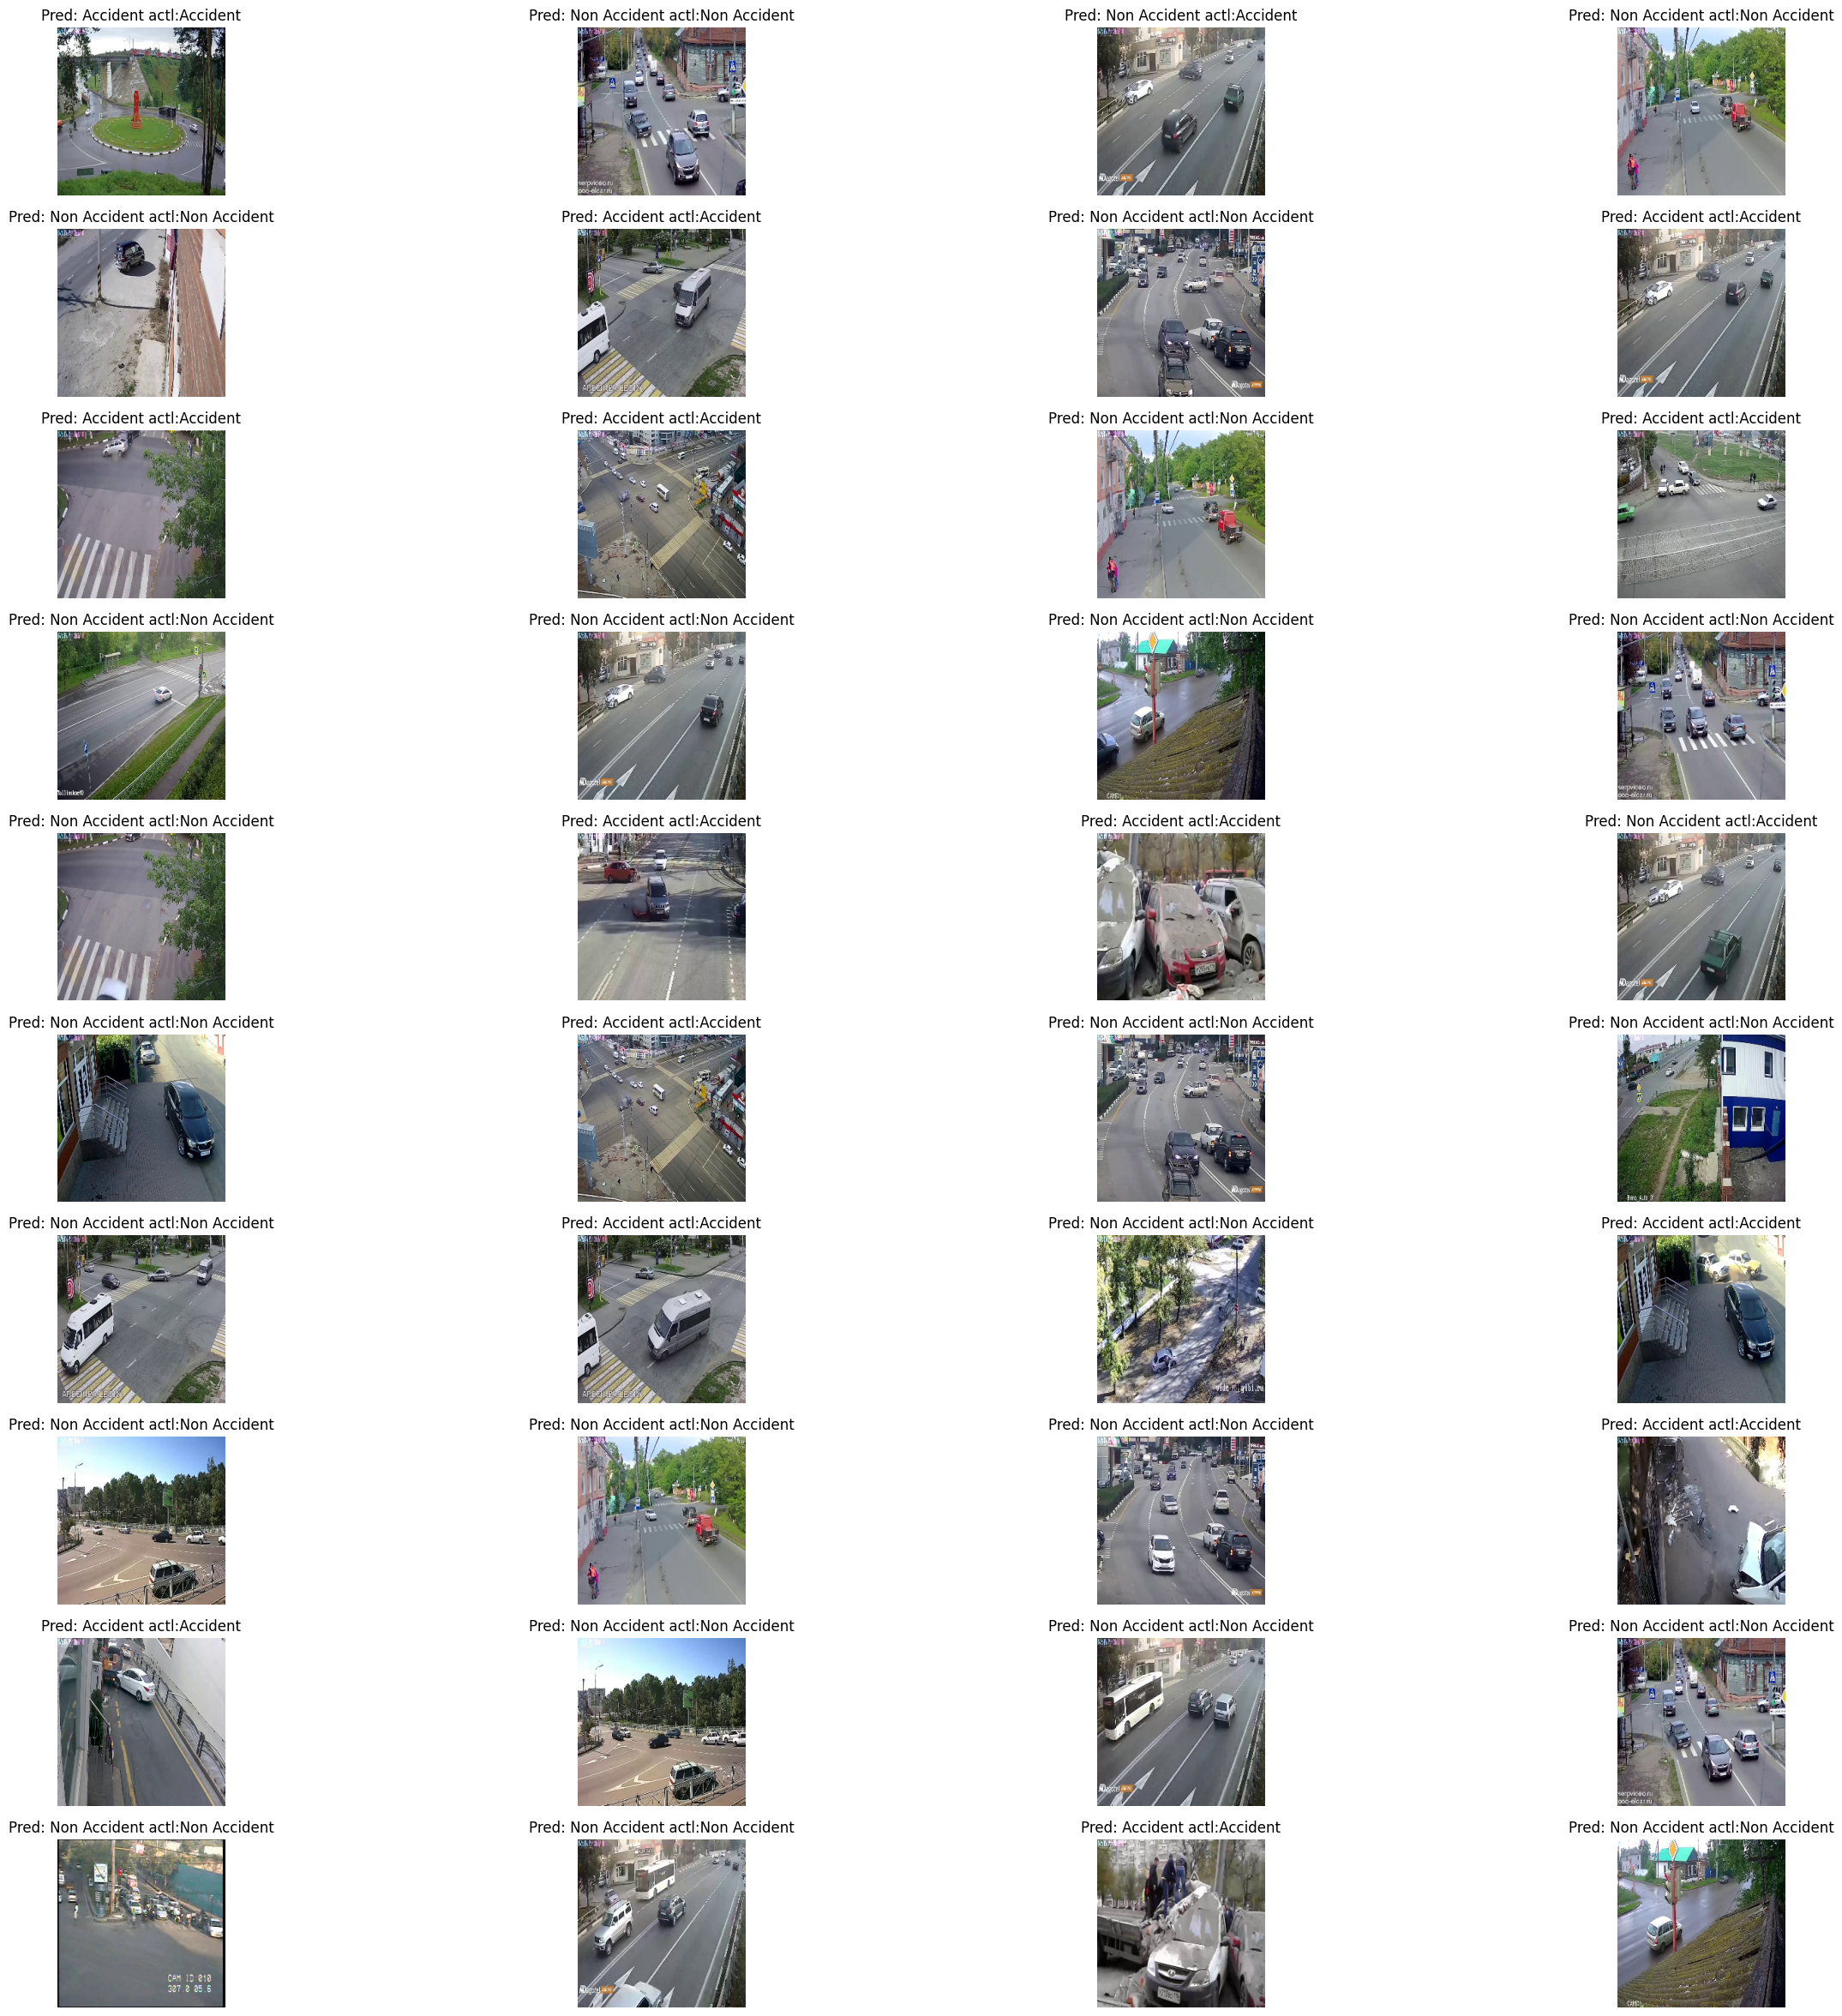

In [16]:
## lets vizualize results on testing data
AccuracyVector = []
plt.figure(figsize=(30, 30))
for images, labels in testing_data.take(1):
    predictions = model.predict(images)
    predlabel = []
    prdlbl = []
    
    for mem in predictions:
        predlabel.append(class_names[np.argmax(mem)])
        prdlbl.append(np.argmax(mem))
    
    AccuracyVector = np.array(prdlbl) == labels
    for i in range(40):
        ax = plt.subplot(10, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title('Pred: '+ predlabel[i]+' actl:'+class_names[labels[i]] )
        plt.axis('off')
        plt.grid(True)